In [1]:
import sys, os

import numpy as np
import scipy as sp

import matplotlib.pyplot as plt

import illustris_python as il

In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [3]:
# Illustris data directory
basePath = 'TNG100-1/output/'

# Hubble parameter
h = 0.704

# Load FoF group catalog
group_fields = ['GroupMass', 'GroupBHMass', 'Group_M_Crit200']
groups = il.groupcat.loadHalos(basePath, 99, fields=group_fields)

# Load Subfind group catalog
subhalo_fields = ['SubhaloMass', 'SubhaloBHMass', 'SubhaloMassType', 'SubhaloVelDisp', 'SubhaloSFRinRad', 'SubhaloVmax']
subhalos = il.groupcat.loadSubhalos(basePath, 99, fields=subhalo_fields)

## Step 1
After identifying the data columns you wish to use, plot the relationship between dark matter halo mass (x-axis) and black hole mass (y-axis) for both subhalo (SubFind) and group (FoF) quantities. These plots must be included in the assignment you turn in, in addition to a short description of which data columns you used and why. If you performed any additional data cleaning or alteration you should summarize it here as well. Given the data volume you should think about how to present this data most clearly.

In [4]:
# ----------------------------
# DATA LOADING / PREPARATION
# ----------------------------

# Convert to physical Msun using: M = value * 1e10 / h.

# --- SubFind masses ---
subhalo_mass    = subhalos['SubhaloMass']   * 1e10 / h
subhalo_bh_mass = subhalos['SubhaloBHMass'] * 1e10 / h

# --- FoF masses ---
group_mass_fof   = groups['GroupMass']        * 1e10 / h
group_mass_200c  = groups['Group_M_Crit200']  * 1e10 / h
group_bh_mass    = groups['GroupBHMass']      * 1e10 / h

# --- Basic statistics ---
print("SubFind SubhaloMass:",    sp.stats.describe(subhalo_mass))
print("SubFind SubhaloBHMass:",  sp.stats.describe(subhalo_bh_mass))
print("FoF GroupMass:",          sp.stats.describe(group_mass_fof))
print("FoF M200c:",              sp.stats.describe(group_mass_200c))
print("FoF GroupBHMass:",        sp.stats.describe(group_bh_mass))

# --- Masks: require positive masses for log-space analysis ---
m_sf = (
    np.isfinite(subhalo_mass) &
    np.isfinite(subhalo_bh_mass) &
    (subhalo_mass > 0) &
    (subhalo_bh_mass > 0)
)

m_fof_mass = (
    np.isfinite(group_mass_fof) &
    np.isfinite(group_bh_mass) &
    (group_mass_fof > 0) &
    (group_bh_mass > 0)
)

m_fof_200c = (
    np.isfinite(group_mass_200c) &
    np.isfinite(group_bh_mass) &
    (group_mass_200c > 0) &
    (group_bh_mass > 0)
)

print(f"\nSubFind valid: {m_sf.sum():,} / {subhalo_mass.size:,}")
print(f"FoF (GroupMass) valid: {m_fof_mass.sum():,} / {group_mass_fof.size:,}")
print(f"FoF (M200c) valid: {m_fof_200c.sum():,} / {group_mass_200c.size:,}")


# --- Helper: binned median trend ---
def binned_trend(x, y, nbins=40):
    lx = np.log10(x)
    ly = np.log10(y)

    bins = np.linspace(lx.min(), lx.max(), nbins + 1)
    idx = np.digitize(lx, bins) - 1

    x_c, y_med, y_p16, y_p84 = [], [], [], []

    for i in range(nbins):
        m = idx == i
        if m.sum() < 50:
            continue

        x_c.append(10**(0.5 * (bins[i] + bins[i+1])))
        y_med.append(10**(np.median(ly[m])))
        y_p16.append(10**(np.percentile(ly[m], 16)))
        y_p84.append(10**(np.percentile(ly[m], 84)))

    return np.array(x_c), np.array(y_med), np.array(y_p16), np.array(y_p84)

SubFind SubhaloMass: DescribeResult(nobs=np.int64(4371211), minmax=(np.float32(1.1782911e+07), np.float32(3.903116e+14)), mean=np.float32(5.6582743e+09), variance=np.float32(2.2964793e+23), skewness=np.float32(inf), kurtosis=np.float32(nan))
SubFind SubhaloBHMass: DescribeResult(nobs=np.int64(4371211), minmax=(np.float32(0.0), np.float32(1.1908019e+10)), mean=np.float32(351537.03), variance=np.float32(3.6038876e+14), skewness=np.float32(239.35983), kurtosis=np.float32(inf))
FoF GroupMass: DescribeResult(nobs=np.int64(6291349), minmax=(np.float32(3.431482e+07), np.float32(5.522448e+14)), mean=np.float32(4.21e+09), variance=np.float32(2.7134793e+23), skewness=np.float32(inf), kurtosis=np.float32(nan))
FoF M200c: DescribeResult(nobs=np.int64(6291349), minmax=(np.float32(0.0), np.float32(3.667457e+14)), mean=np.float32(3.142935e+09), variance=np.float32(1.4213575e+23), skewness=np.float32(inf), kurtosis=np.float32(nan))
FoF GroupBHMass: DescribeResult(nobs=np.int64(6291349), minmax=(np.flo

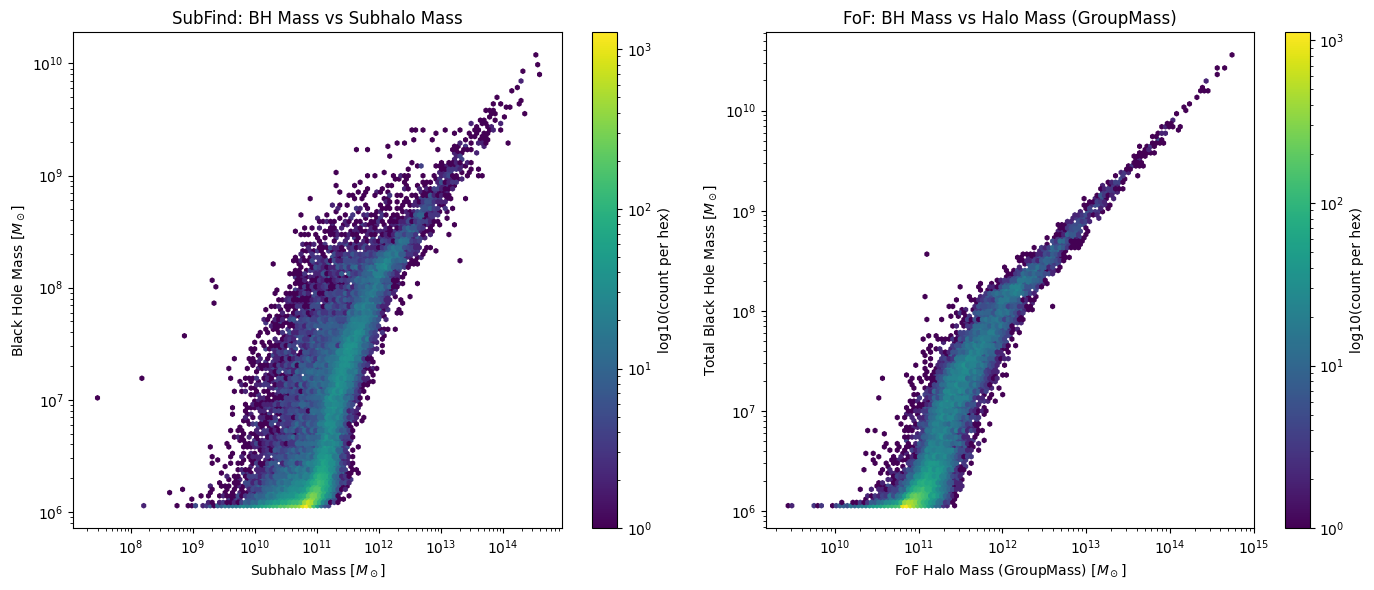

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ---- SubFind ----
hb0 = ax[0].hexbin(
    subhalo_mass[m_sf], subhalo_bh_mass[m_sf],
    gridsize=120, xscale="log", yscale="log",
    bins="log"
)
cbar0 = fig.colorbar(hb0, ax=ax[0])
cbar0.set_label("log10(count per hex)")

ax[0].set_xlabel(r"Subhalo Mass [$M_\odot$]")
ax[0].set_ylabel(r"Black Hole Mass [$M_\odot$]")
ax[0].set_title("SubFind: BH Mass vs Subhalo Mass")

# Justification:
#   SubhaloMass = total bound mass of the subhalo (galaxy-scale bound structure)
#   SubhaloBHMass = total BH mass within that subhalo
#   → probes BH–(sub)halo relation at the galaxy/subhalo scale

# ---- FoF (GroupMass) ----
hb1 = ax[1].hexbin(
    group_mass_fof[m_fof_mass], group_bh_mass[m_fof_mass],
    gridsize=120, xscale="log", yscale="log",
    bins="log"
)
cbar1 = fig.colorbar(hb1, ax=ax[1])
cbar1.set_label("log10(count per hex)")

ax[1].set_xlabel(r"FoF Halo Mass (GroupMass) [$M_\odot$]")
ax[1].set_ylabel(r"Total Black Hole Mass [$M_\odot$]")
ax[1].set_title("FoF: BH Mass vs Halo Mass (GroupMass)")

# Justification:
#   GroupMass = total mass of all particle types assigned to the FoF halo by linking length b=0.2
#   GroupBHMass = sum of BH masses over the entire FoF halo
#   → probes BH–host halo relation using the FoF mass definition

plt.tight_layout()
plt.show()

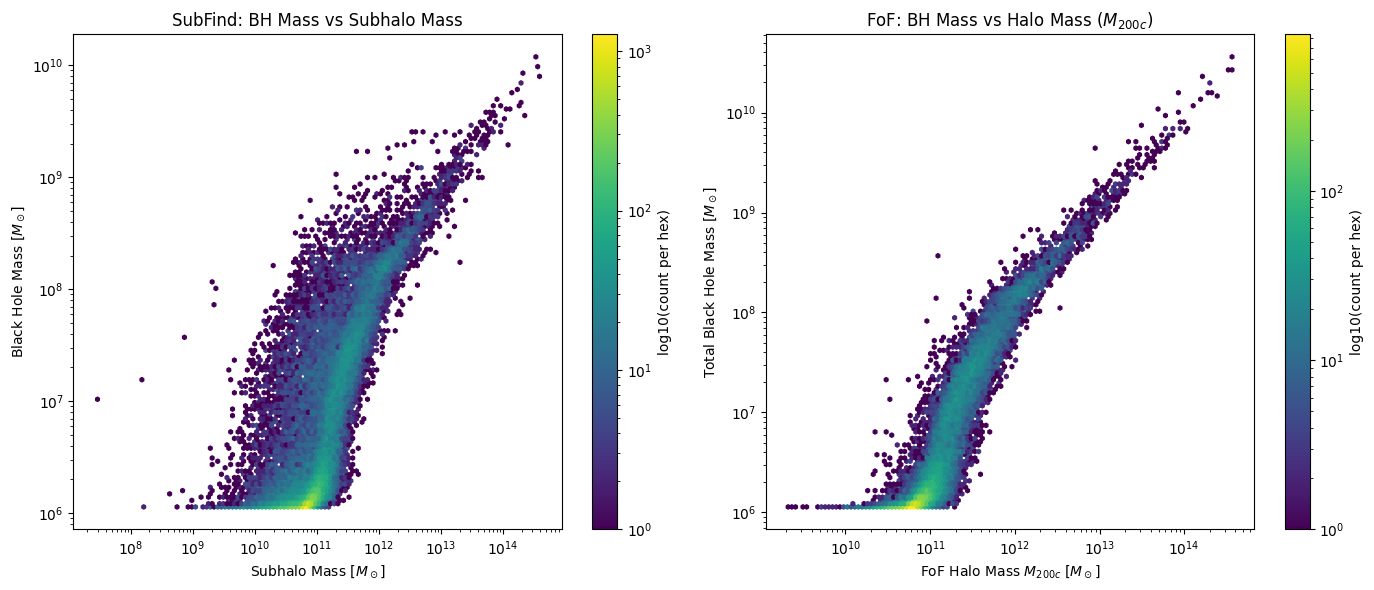

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ---- SubFind ----
hb0 = ax[0].hexbin(
    subhalo_mass[m_sf], subhalo_bh_mass[m_sf],
    gridsize=120, xscale="log", yscale="log",
    bins="log"
)
cbar0 = fig.colorbar(hb0, ax=ax[0])
cbar0.set_label("log10(count per hex)")

ax[0].set_xlabel(r"Subhalo Mass [$M_\odot$]")
ax[0].set_ylabel(r"Black Hole Mass [$M_\odot$]")
ax[0].set_title("SubFind: BH Mass vs Subhalo Mass")

# Justification:
#   SubhaloMass = total bound mass of the subhalo (galaxy-scale bound structure)
#   SubhaloBHMass = total BH mass within that subhalo
#   → probes BH–(sub)halo relation at the galaxy/subhalo scale

# ---- FoF (M200c) ----
hb1 = ax[1].hexbin(
    group_mass_200c[m_fof_200c], group_bh_mass[m_fof_200c],
    gridsize=120, xscale="log", yscale="log",
    bins="log"
)
cbar1 = fig.colorbar(hb1, ax=ax[1])
cbar1.set_label("log10(count per hex)")

ax[1].set_xlabel(r"FoF Halo Mass $M_{200c}$ [$M_\odot$]")
ax[1].set_ylabel(r"Total Black Hole Mass [$M_\odot$]")
ax[1].set_title(r"FoF: BH Mass vs Halo Mass ($M_{200c}$)")

# Justification:
#   Group_M_Crit200 = spherical-overdensity mass within R200c (200× critical density),
#   a standard “virial mass” definition used in cosmology/galaxy formation literature.
#   GroupBHMass = sum of BH masses over the entire FoF halo
#   → probes BH–host halo relation using a standard SO mass definition

plt.tight_layout()
plt.show()

# Step 2
Come up with a reasonable physical equation relating the black hole mass to the halo mass. You do not need to estimate physical constants, but you should explain why you chose the scaling that you did. Hypothesize as to the physical mechanisms that could give rise to such a relationship between these parameters.

A natural physical model relating black hole mass to halo mass is a power-law scaling,

$M_{\rm BH} \propto M_{\rm halo}^{\alpha}.$

Such relations commonly arise in hierarchical structure formation, where gravitational growth, gas accretion, and mergers proceed in a scale-free manner. More massive halos possess deeper gravitational potential wells, allowing them to retain gas more efficiently and sustain prolonged accretion onto central black holes. Additionally, the merger histories of massive halos promote black hole coalescence and growth. Feedback from active galactic nuclei further regulates this process, establishing an equilibrium between accretion and energy injection into the surrounding medium.

The approximate linear trend observed in log–log space between halo mass and black hole mass in the IllustrisTNG data supports the use of a power-law model. Similar scaling relations have been identified in both simulations and observations, including correlations between black hole mass and galaxy bulge mass, velocity dispersion, and halo properties. These considerations motivate adopting a power-law relation as a physically reasonable description of the black hole–halo mass connection.

# Step 3
Determine if there is a difference in the relation between the SubFind and FoF catalogs. Form a
hypothesis as to why there should or should not be a difference and include it in your write-up.

The relation between black hole mass and halo mass differs between the SubFind and FoF catalogs due to the different physical scales represented by these structures. SubFind subhalos correspond to individual galaxies, including both central and satellite systems, whereas FoF groups represent entire dark matter halos containing multiple galaxies and diffuse material.

At low halo masses, the SubFind relation shows increased scatter compared to the FoF relation. This is likely driven by the black hole seeding prescription in the simulation, in which black holes are introduced only once halos exceed a minimum mass threshold and begin with a fixed seed mass. As a result, many low-mass subhalos contain either no black hole or a newly seeded black hole of similar mass, producing significant dispersion in the relation.

Additional scatter arises from tidal stripping and environmental effects. Satellite subhalos may lose dark matter mass while retaining their central black holes, further broadening the relation at low mass.

In contrast, FoF halos aggregate the mass of multiple galaxies and their black holes, smoothing the relation at higher masses but still displaying scatter at the low-mass end where black hole occupation fractions vary. At high halo masses, both relations become tighter as black hole growth is dominated by mergers and sustained gas accretion, leading to a more self-regulated scaling between black hole and halo mass.

These differences highlight that the SubFind relation probes black hole–galaxy co-evolution, while the FoF relation reflects the connection between black holes and the assembly of their host dark matter halos.

# Step 4
Plot the relation between galaxy stellar mass and black hole mass and comment on it briefly. Is it
tighter or more scattered than the halo mass – black hole mass relation? Is the correlation what you
expected? And so on. You may provide other supporting plots here if you wish.

N total=4,371,211 | N valid (M*>0 & MBH>0)=36,926
M* min/max: 746565.25 3.5655726e+12
MBH min/max: 1.1363636e+06 1.1908019e+10


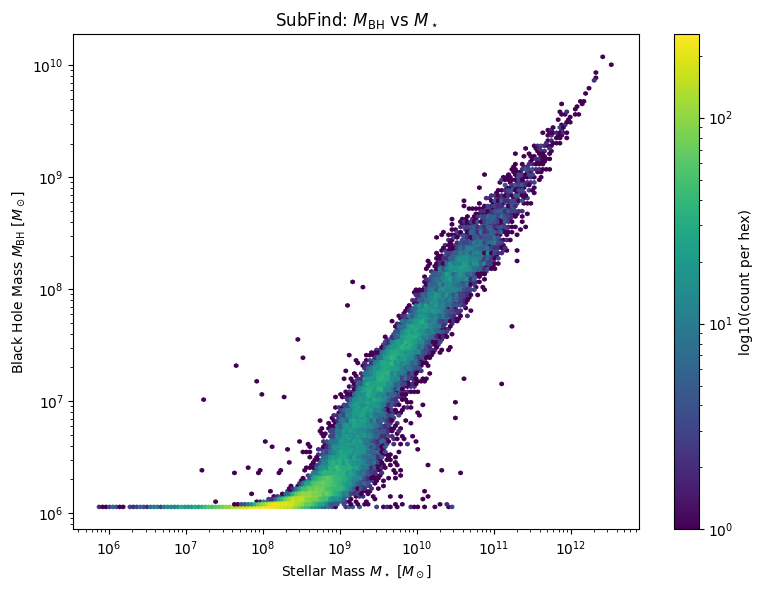

In [7]:
# Type 4 = stars
mstar = subhalos["SubhaloMassType"][:, 4] * 1e10 / h
mbh   = subhalos["SubhaloBHMass"] * 1e10 / h

# --- mask for log plots ---
m = np.isfinite(mstar) & np.isfinite(mbh) & (mstar > 0) & (mbh > 0)

print(f"N total={mstar.size:,} | N valid (M*>0 & MBH>0)={m.sum():,}")
print("M* min/max:", mstar[m].min(), mstar[m].max())
print("MBH min/max:", mbh[m].min(), mbh[m].max())

fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(
    mstar[m], mbh[m],
    gridsize=150,
    xscale="log", yscale="log",
    bins="log"
)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("log10(count per hex)")

ax.set_xlabel(r"Stellar Mass $M_\star$ [$M_\odot$]")
ax.set_ylabel(r"Black Hole Mass $M_{\rm BH}$ [$M_\odot$]")
ax.set_title(r"SubFind: $M_{\rm BH}$ vs $M_\star$")

plt.tight_layout()
plt.show()

# Justification:
#   SubhaloMassType[:,4] = stellar mass (Type 4 = stars), isolates the galaxy component (not DM+gas).
#   SubhaloBHMass = total BH mass in the subhalo.
#   → probes the BH–galaxy (stellar mass) relation directly.

# Step 5
Explore the data columns to identify another column that is correlated with black hole mass. Plot
the relation and hypothesize as to the origin of the correlation.

Valid counts:
  sigma: 36,941
  Mstar: 36,926
  SFR:   31,511
  Mgas:  33,896
  Vmax:  36,941


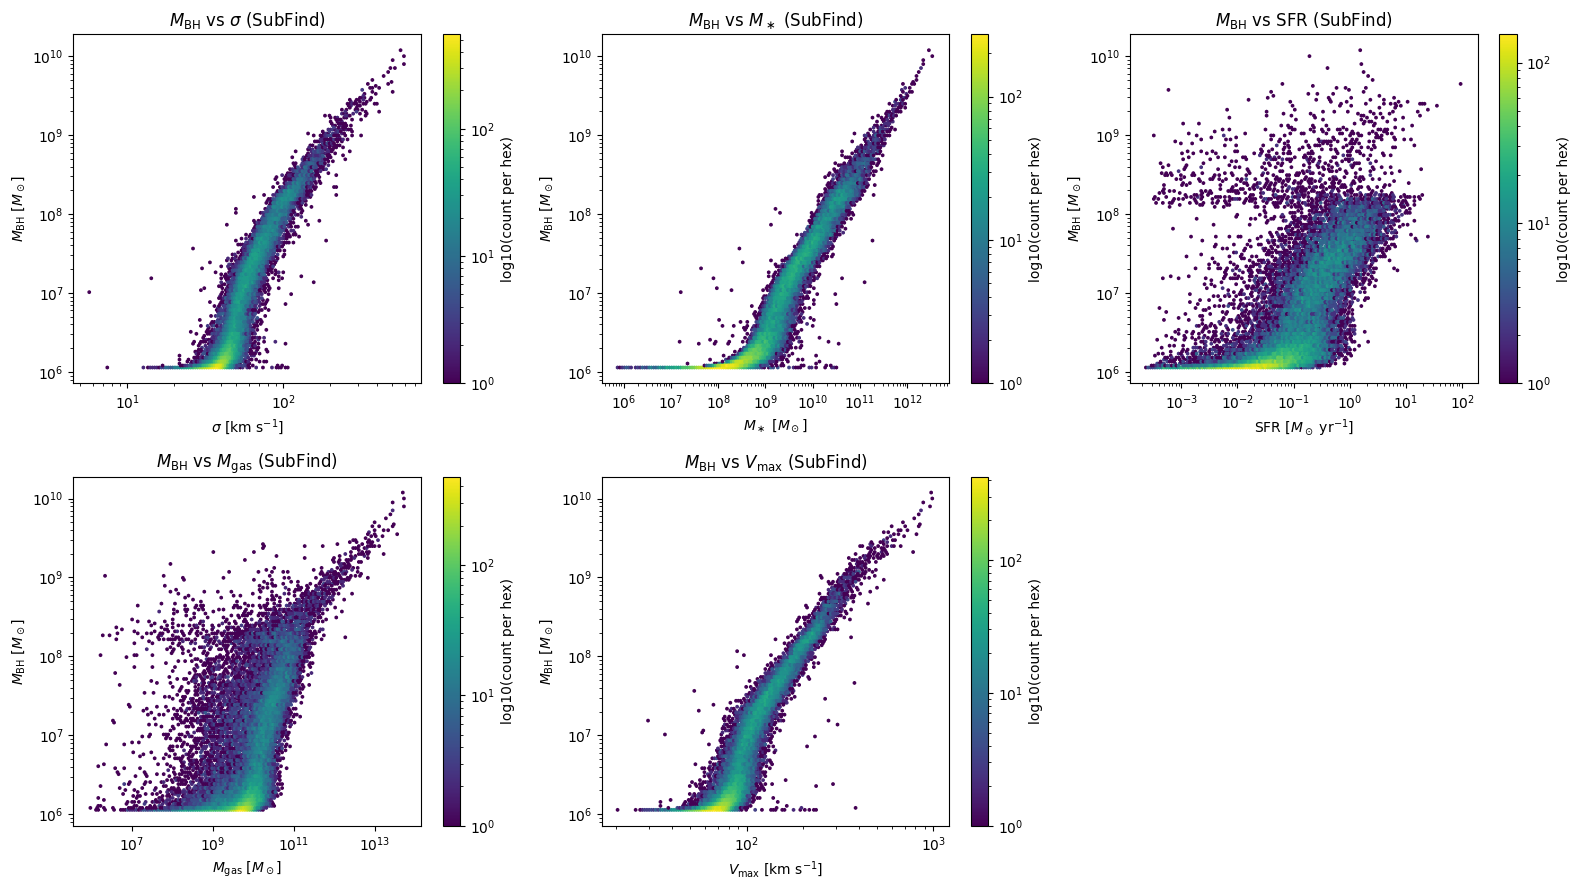

In [ ]:
# -----------------------------------------
# STEP 5 — Explore correlations with MBH
# Panels: sigma, M*, SFR, Mgas, Vmax
# -----------------------------------------
#  - SubhaloVelDisp (sigma): M_BH–sigma relation supported by literature. sigma traces central potential depth.
#  - Stellar mass (M*): feels self explanatory; links BH growth to galaxy buildup
#  - SFR: tests whether BH mass tracks ongoing star formation
#  - Gas mass (Mgas): does BH mass correlate with gas reservoir for star formation?
#  - Vmax: traces halo/galaxy potential depth

MBH = subhalos["SubhaloBHMass"] * 1e10 / h  # Msun

sigma = subhalos["SubhaloVelDisp"]          # km/s
Mstar = subhalos["SubhaloMassType"][:, 4] * 1e10 / h  # Type 4 = stars, Msun
SFR   = subhalos["SubhaloSFRinRad"]              # Msun/yr
Mgas  = subhalos["SubhaloMassType"][:, 0] * 1e10 / h  # Type 0 = gas, Msun
Vmax  = subhalos["SubhaloVmax"]             # km/s

def finite_pos(*arrs):
    m = np.ones_like(arrs[0], dtype=bool)
    for a in arrs:
        m &= np.isfinite(a) & (a > 0)
    return m

# Masks for each panel (ensure log-safe)
m_sigma = finite_pos(sigma, MBH)
m_star  = finite_pos(Mstar, MBH)
m_sfr   = finite_pos(SFR, MBH)
m_gas   = finite_pos(Mgas, MBH)
m_vmax  = finite_pos(Vmax, MBH)

print(f"Valid counts:")
print(f"  sigma: {m_sigma.sum():,}")
print(f"  Mstar: {m_star.sum():,}")
print(f"  SFR:   {m_sfr.sum():,}")
print(f"  Mgas:  {m_gas.sum():,}")
print(f"  Vmax:  {m_vmax.sum():,}")

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

# Helper to make consistent hexbin + colorbar
def hexpanel(ax, x, y, mask, xlabel, title, xlog=True, ylog=True, gridsize=140):
    hb = ax.hexbin(
        x[mask], y[mask],
        gridsize=gridsize,
        xscale="log" if xlog else "linear",
        yscale="log" if ylog else "linear",
        bins="log"
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$M_{\rm BH}$ [$M_\odot$]")
    ax.set_title(title)
    cbar = fig.colorbar(hb, ax=ax)
    cbar.set_label("log10(count per hex)")
    return hb

# 1) MBH vs sigma
hexpanel(
    axes[0], sigma, MBH, m_sigma,
    xlabel=r"$\sigma$ [km s$^{-1}$]",
    title=r"$M_{\rm BH}$ vs $\sigma$ (SubFind)",
    xlog=True, ylog=True
)

# 2) MBH vs stellar mass
hexpanel(
    axes[1], Mstar, MBH, m_star,
    xlabel=r"$M_\ast$ [${M_\odot}$]",
    title=r"$M_{\rm BH}$ vs $M_\ast$ (SubFind)",
    xlog=True, ylog=True
)

# 3) MBH vs SFR  (often has lots of zeros, but mask removed them)
# SFR spans many decades; log is usually still best.
hexpanel(
    axes[2], SFR, MBH, m_sfr,
    xlabel=r"SFR [${M_\odot}$ yr$^{-1}$]",
    title=r"$M_{\rm BH}$ vs SFR (SubFind)",
    xlog=True, ylog=True
)

# 4) MBH vs gas mass
hexpanel(
    axes[3], Mgas, MBH, m_gas,
    xlabel=r"$M_{\rm gas}$ [${M_\odot}$]",
    title=r"$M_{\rm BH}$ vs $M_{\rm gas}$ (SubFind)",
    xlog=True, ylog=True
)

# 5) MBH vs Vmax
hexpanel(
    axes[4], Vmax, MBH, m_vmax,
    xlabel=r"$V_{\max}$ [km s$^{-1}$]",
    title=r"$M_{\rm BH}$ vs $V_{\max}$ (SubFind)",
    xlog=True, ylog=True
)

# 6th panel unused, hide
axes[5].axis("off")

plt.tight_layout()
plt.show()

# Step 6
Comment on any limitations of the data products that you believe may impact the above
relations. If your work were to be published in a journal paper, what concerns would you have?

# ASTR 5140 Only

# Step 1
Make cuts on the halo catalog to identify a list of subhalos with well-defined black hole masses and velocity dispersions (SubFind field [`SubhaloVelDisp`]). Summarize your cuts and plot this relation. Fit a model of your own design to this relation via least-squares or other similar technique. Comment on your result.

# Step 2
Review section 14.2 of Galaxy Formation and Evolution by Mo, van den Bosch & White – see the “background” section above for a link to read the ebook on the UVA library website. Assume all black holes accrete at their Eddington luminosities and compute the corresponding AGN luminosities for the galaxies you selected from IllustrisTNG.

a. Calculate and plot the average AGN luminosity as a function halo mass.

b. Plot the distribution (histogram) of AGN luminosities.

c. What fraction of halos in TNG100-1 have Eddington AGN luminosities (as computed above) greater than 1.28e46 ergs / s?

# Step 3 
Now examine the actual black hole accretion rates as listed in the TNG catalogs.

a. Make a plot comparing the black hole accretion rates in the TNG catalogs to the Eddington mass accretion rate as a function of halo mass Discuss whether the TNG results are consistent with Eddington accretion.

b. Let the efficiency of converting mass accretion into luminosity (εr in the reading) be 0.1. Compute AGN luminosities for the galaxies you selected from IllustrisTNG using the black hole accretion rates in the TNG catalogs. Plot the average AGN luminosity calculated this way as a function of halo mass and compare to the same plot you made in 2a) above assuming Eddington mass accretion. Plot the distribution of AGN luminosities and compare to the plot from 2b) above. What fraction of halos in TNG100-1 have AGN luminosities greater than 1.28e46 ergs / s when using the TNG mass accretion rates? How does this compare to your answer from 2c) where you assumed Eddington accretion? Comment on how the assumption of Eddington accretion rates may affect predictions for the frequency of observing bright quasars.